# Constructing Toy Dataset

In [1]:
# auto reload modified modules
%load_ext autoreload
%autoreload 2

import numpy as np
import math
import torch 
import torch.nn as nn
from torch.nn import functional as F 
from distributions import *
from utils import *
from data_utils import *
from plot_utils import *
from copy import deepcopy
from tqdm import tqdm
import seaborn as sns
sns.set()
# plot_setting()
seed = 1

### Input PDF

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
# dimension of the problem
d = 2 

# grid points
N = 100
X1, X2 = torch.meshgrid(torch.linspace(-8,8, N), \
                              torch.linspace(-8,8, N), indexing='ij')
GRIDS = torch.cat((X1.reshape(-1,1),X2.reshape(-1,1)), dim=1)

# define input distribution 
mu_in = torch.zeros(d)
var_in = 9
cov_in = torch.eye(d) * var_in
option_in = 'mvn'
input_sampler = input(mu_in, cov_in, option_in)

# Latin Hypercube Samples
# N_LHS = 10000
# lh_mult = 6*np.sqrt(var_in)
# lh_lbounds = -lh_mult * np.ones(d)
# lh_ubounds = lh_mult * np.ones(d)
# p_lhs = lambda x : 1 / (4*lh_mult**2) * np.ones_like(x)
# LHS = get_lhs(d, N_LHS, l_bounds=lh_lbounds, u_bounds=lh_ubounds)
# LHS = lhs_to_gaussian(N=N_LHS,d=d, scale=np.sqrt(var_in))

# get input pdf values on grid points
input_pdf = input_sampler.pdf(GRIDS)
input_pdf = input_pdf.reshape(N,N)

### Define Input-Output Mapping

In [3]:
# # define output map 2
# locs = [
#     [1,1],
#     [-1,-1],
#     [4,-4],
#     [0,1],
#     [0.5,-0.5],
#     [-2,2]
# ]
# vars = np.asarray([
#     0.5, 0.5, 0.2, .9, .6, 1
# ])
# covs = np.asarray([
#     torch.eye(d) * var for var in vars
# ])
# covs = torch.from_numpy(covs)
# heights = torch.Tensor([
#     2, 2, 1., .5, 1.25, 0
# ])

# mapping = true_map(locs, covs, heights)

# define output map 1
exloc = 2.
locs = [
    [2,2],
    [-1,-1],
    [exloc,-exloc],
    [0,1],
    [0.5,-0.5],
    [-2,2]
]
vars = np.asarray([
    0.5, 0.7, 0.3, .9, .6, 1
])
covs = np.asarray([
    torch.eye(d) * var for var in vars
])
covs = torch.from_numpy(covs)
heights = torch.Tensor([
    1.5, 1.5, 1., .5, 1.25, 0
])

mapp = true_map(locs, covs, heights)
def mapping(x):
    y = mapp(x).view(-1,1)
    return torch.cat((y,y),1)

def c(y):
    return torch.pow(y[:,0],2) + 2*torch.pow(y[:,1],2)

# get outputs on a grid
OUT_GRID = c(mapping(GRIDS))

### Visualize Outputs

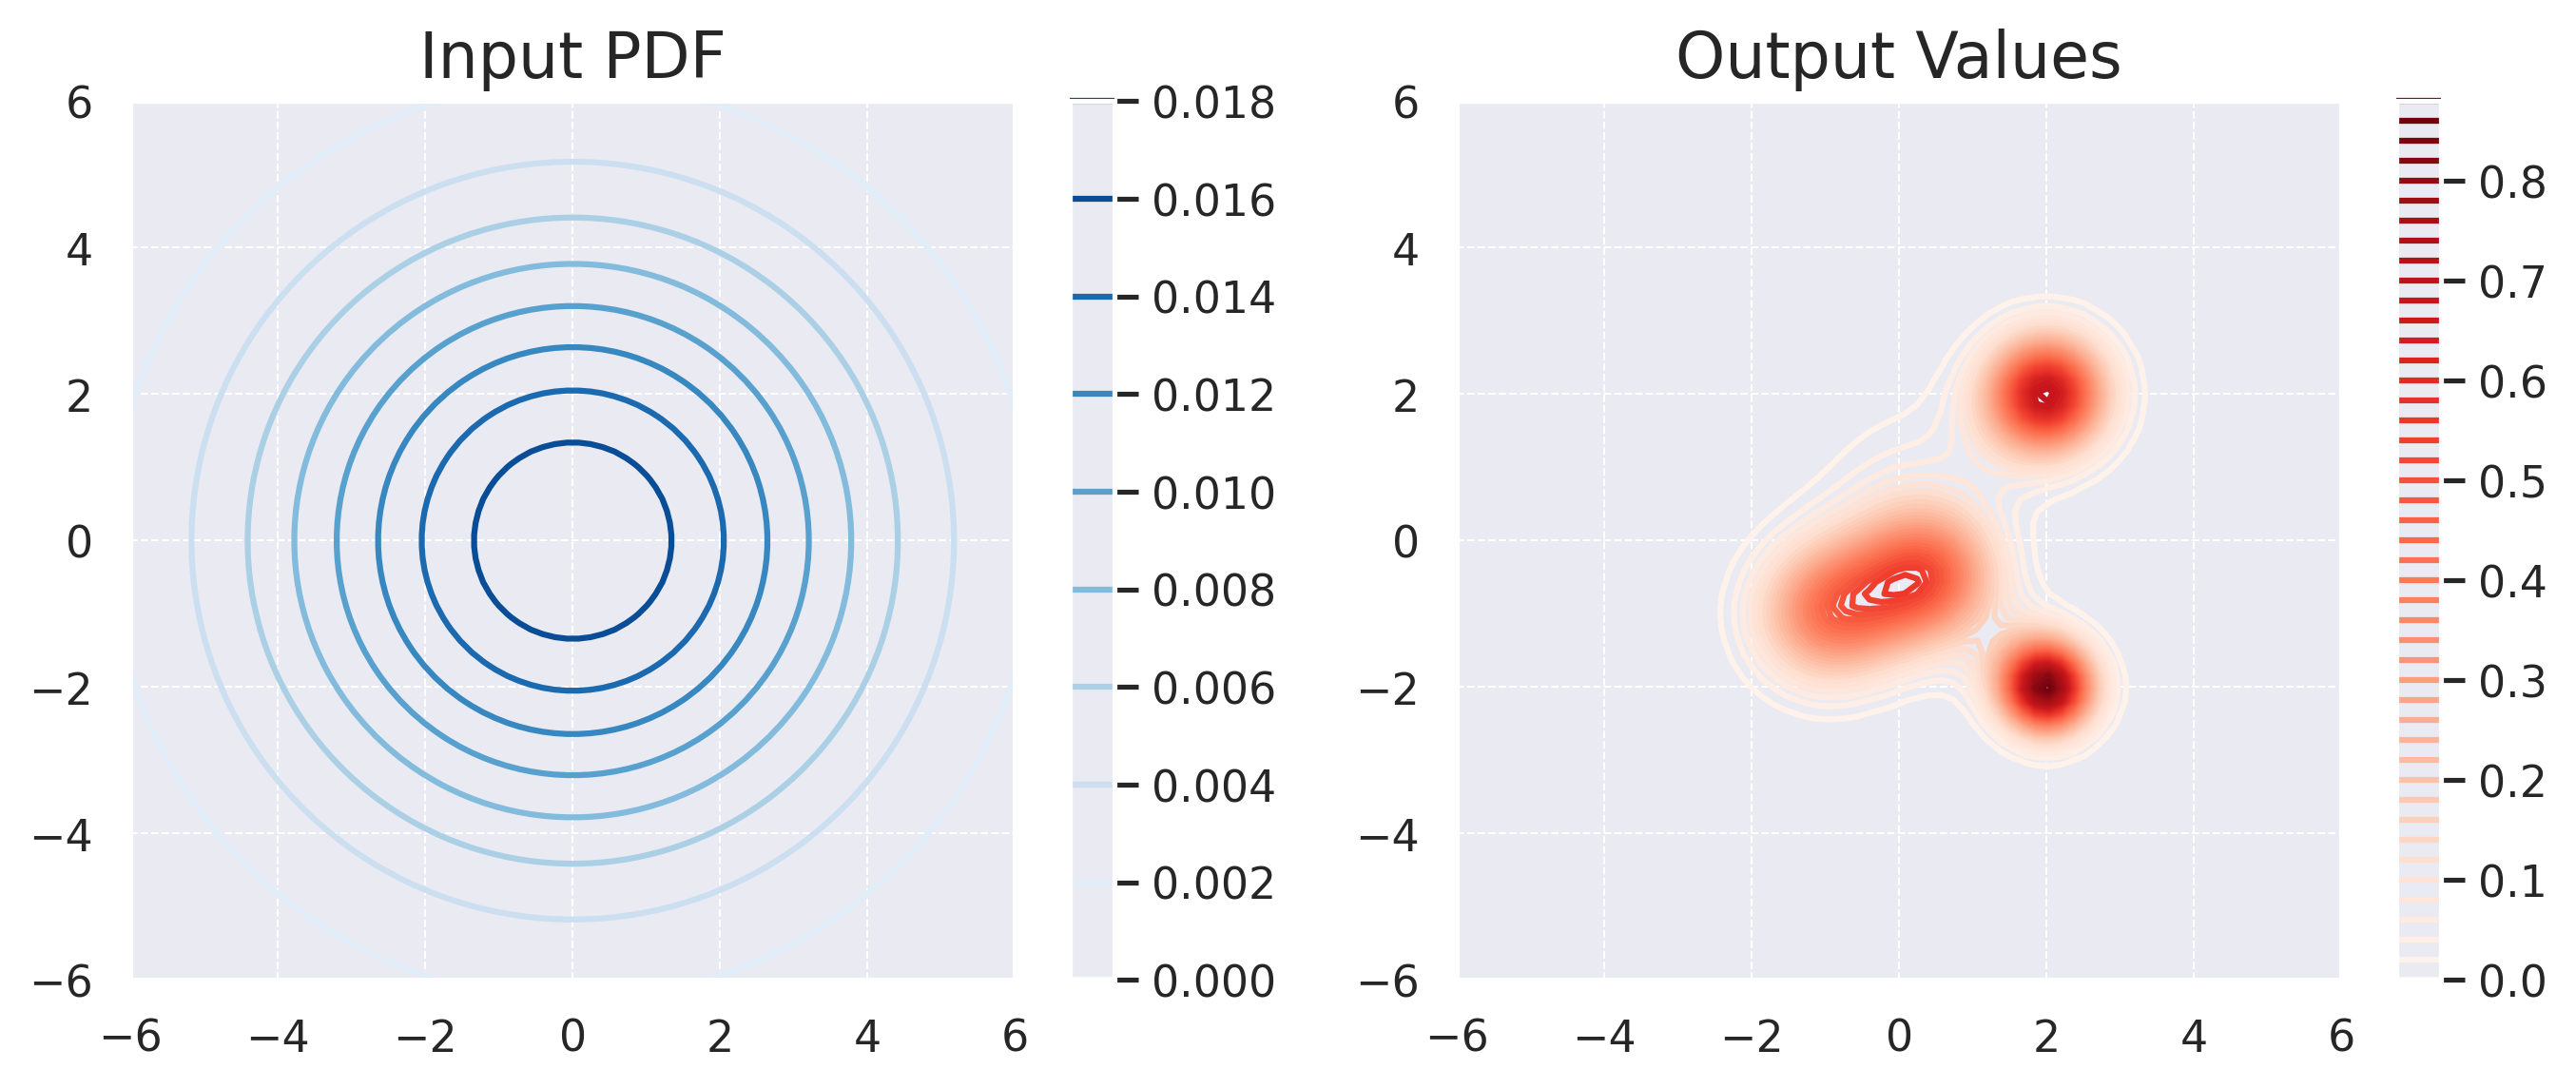

In [7]:
# plot contour
ax_lim = (-6,6)
fig, ax = plt.subplots(1,2,figsize=(11,4), facecolor='w', dpi=300)
plt1 = ax[0].contour(X1.numpy(),X2.numpy(),input_pdf.numpy(), 10, cmap='Blues')
plt.colorbar(plt1, ax=ax[0])
ax[0].set_xlim(ax_lim)
ax[0].set_ylim(ax_lim)
ax[0].grid(linestyle='--', linewidth=0.5)
ax[0].set_title("Input PDF", fontsize=16)

plt2 = ax[1].contour(X1.numpy(),X2.numpy(),OUT_GRID.reshape(N,N).numpy(), 48, cmap='Reds')
plt.colorbar(plt2, ax=ax[1])
ax[1].set_xlim(ax_lim)
ax[1].set_ylim(ax_lim)
ax[1].grid(linestyle='--', linewidth=0.5)
ax[1].set_title("Output Values", fontsize=16)
plt.savefig('./figs/true-input-output1.png')


In [15]:
################# SEPARATE PLOTS ##############################################
# ax_lim = (-6,6)
# fig, ax = plt.subplots(facecolor='w', dpi=300)
# plt1 = ax.contour(X1.numpy(),X2.numpy(),input_pdf.numpy(), 10, cmap='Blues')
# plt.colorbar(plt1, ax=ax)
# ax.set_xlim(ax_lim)
# ax.set_ylim(ax_lim)
# ax.grid(linestyle='--', linewidth=0.5)
# plt.savefig('./figs_gennee/true-input-output2.png')

# plt2 = ax.contourf(X1.numpy(),X2.numpy(),OUT_GRID.reshape(N,N).numpy(), 48,alpha = 0.8, cmap='Reds')
# ax.contour(X1.numpy(),X2.numpy(),OUT_GRID.reshape(N,N).numpy(), 48, cmap='Reds')
# plt.colorbar(plt2, ax=ax)
# ax.set_xlim(ax_lim)
# ax.set_ylim(ax_lim)
# ax.grid(linestyle='--', linewidth=0.5)
# plt.savefig('./figs_gennee/true-input-output3.png')

### Output PDF (KDE Approximated)

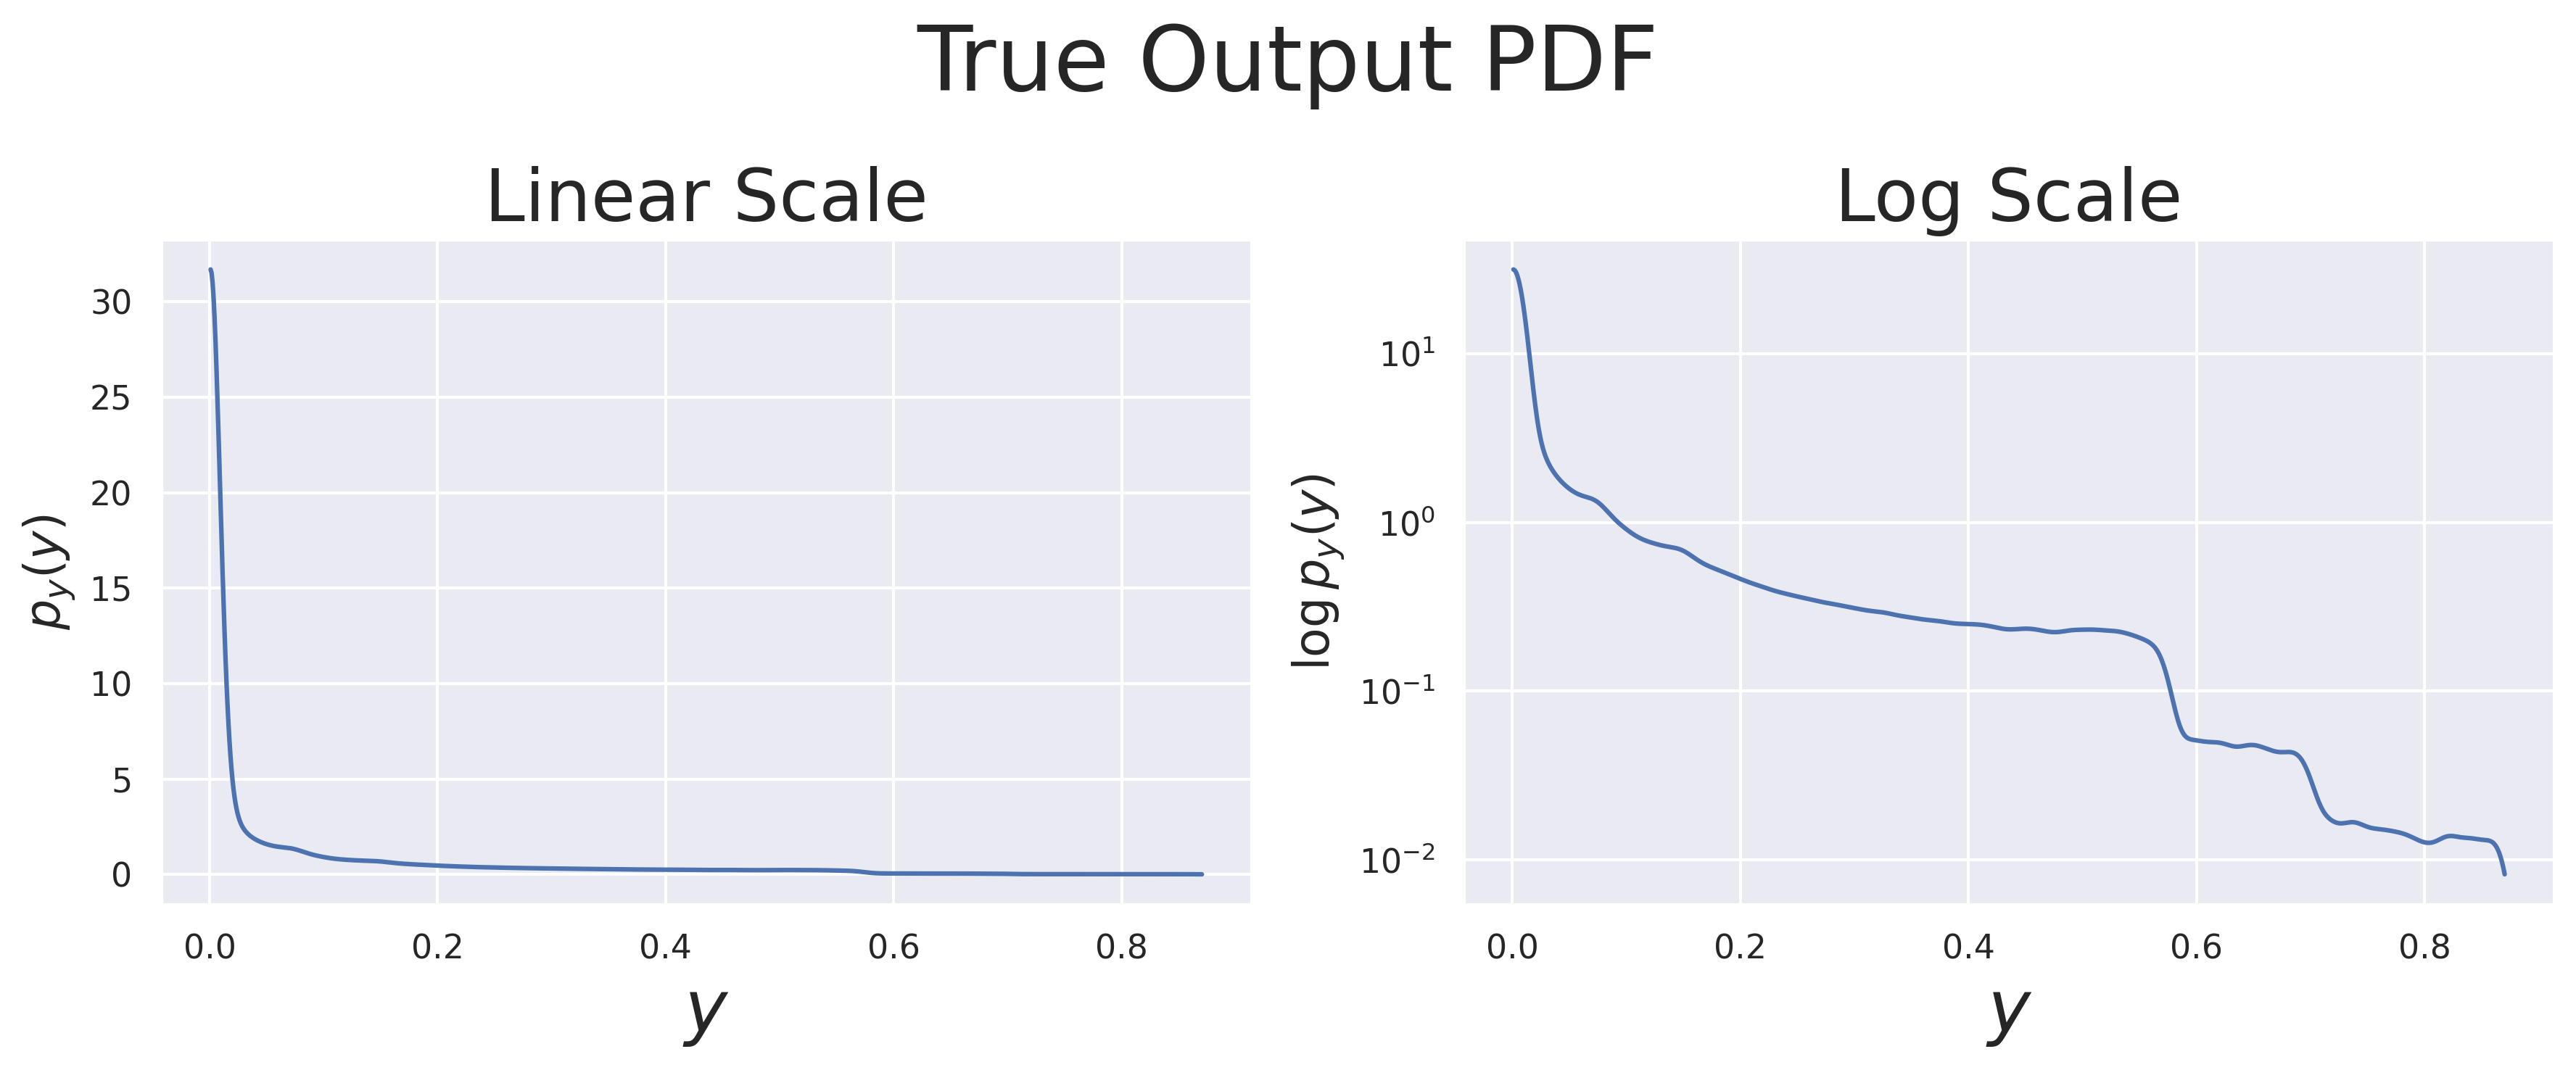

In [16]:
from kde import *
# output density
global_seed(1)
Ns = int(1e6)
X = input_sampler.sample((Ns,))
pX = input_sampler.pdf(X)
Y = c(mapping(X))

def get_data_pdf(data, data_all, weights=None):
    """ 
    Wrapper for computing output pdf 
    """
    if weights is not None:
        if type(weights) is torch.Tensor:
            weights = weights.numpy()
    
    if type(data_all) is torch.Tensor:
        data_all = data_all.numpy()
        
    data_min =  np.min([data.detach().numpy().min(),data_all.min()]) - 1e-8
    data_max =  np.max([data.detach().numpy().max(),data_all.max()]) + 1e-8
    y_eval = np.linspace(data_min, data_max, 1000)
    y_pdf = custom_KDE(data.detach().cpu().numpy(), weights=weights, bw=None)
    py = y_pdf.evaluate(y_eval)
    
    py = py * (y_eval < data_all.max())
    py = py * (y_eval > data_all.min())
    py = np.trim_zeros(py)
    y_eval = y_eval * (y_eval < data_all.max())
    y_eval = y_eval * (y_eval > data_all.min())
    y_eval = np.trim_zeros(y_eval)

    return y_eval, py, y_pdf

# output pdf
true_iw = None
y_true, py_true, true_output_pdf = get_data_pdf(Y, Y, true_iw)

title_true_pdf = "True Output PDF"
fig_true_pdf, ax_true_pdf = plot_pdf(y_true, py_true,# label=fr"True ($N={Ns}$)",
                                     title=title_true_pdf)

ax_true_pdf[0].set_ylabel(r"$p_y(y)$", fontsize=16)
# ax_true_pdf[0].set_xlim(-20,20)
# ax_true_pdf[1].set_xlim(-20,20)
ax_true_pdf[1].set_ylabel(r"$\log{p_y(y)}$", fontsize=16)
fig_true_pdf.tight_layout()
# plt.savefig('./figs/true-output-pdf1.png')

### Criteria to Select Training Data

In [17]:
# check if input gives extreme
def is_not_extreme(x, mult=4.):
    # define extreme region
    loc = locs[2]
    locx = loc[0]
    locy = loc[1]
    extreme_x = [locx-mult*0.3, locx+mult*0.3]
    extreme_y = [locy-mult*0.3, locy+mult*0.3]

    is_extreme = (extreme_x[0] <= x[0]) * (x[0] <= extreme_x[1]) * \
                 (extreme_y[0] <= x[1]) * (x[1] <= extreme_y[1])
    if x.dim() != 1:
        is_extreme = (extreme_x[0] <= x[:,0]) * (x[:,0] <= extreme_x[1]) * \
                 (extreme_y[0] <= x[:,1]) * (x[:,1] <= extreme_y[1])
    return (~is_extreme)

# check if output is too small
def is_not_small(y,thresh=0.00005):
    return (y >= thresh)

### Boxed-Out Region PDF

In [9]:
boxed = is_not_extreme(X)
Y_BOX = Y[boxed.nonzero().squeeze()].squeeze()
X_BOX = X[boxed.nonzero().squeeze()]
# fig, ax = plt.subplots(figsize=(5,4))
# ax.set_title(r"Boxed-Out Data", fontsize=16)
# ax.plot(X_BOX[:,0], X_BOX[:,1], 'o', markersize=.1, color='blue', alpha=1)
# plt.savefig("./figs/boxed-data1.png")

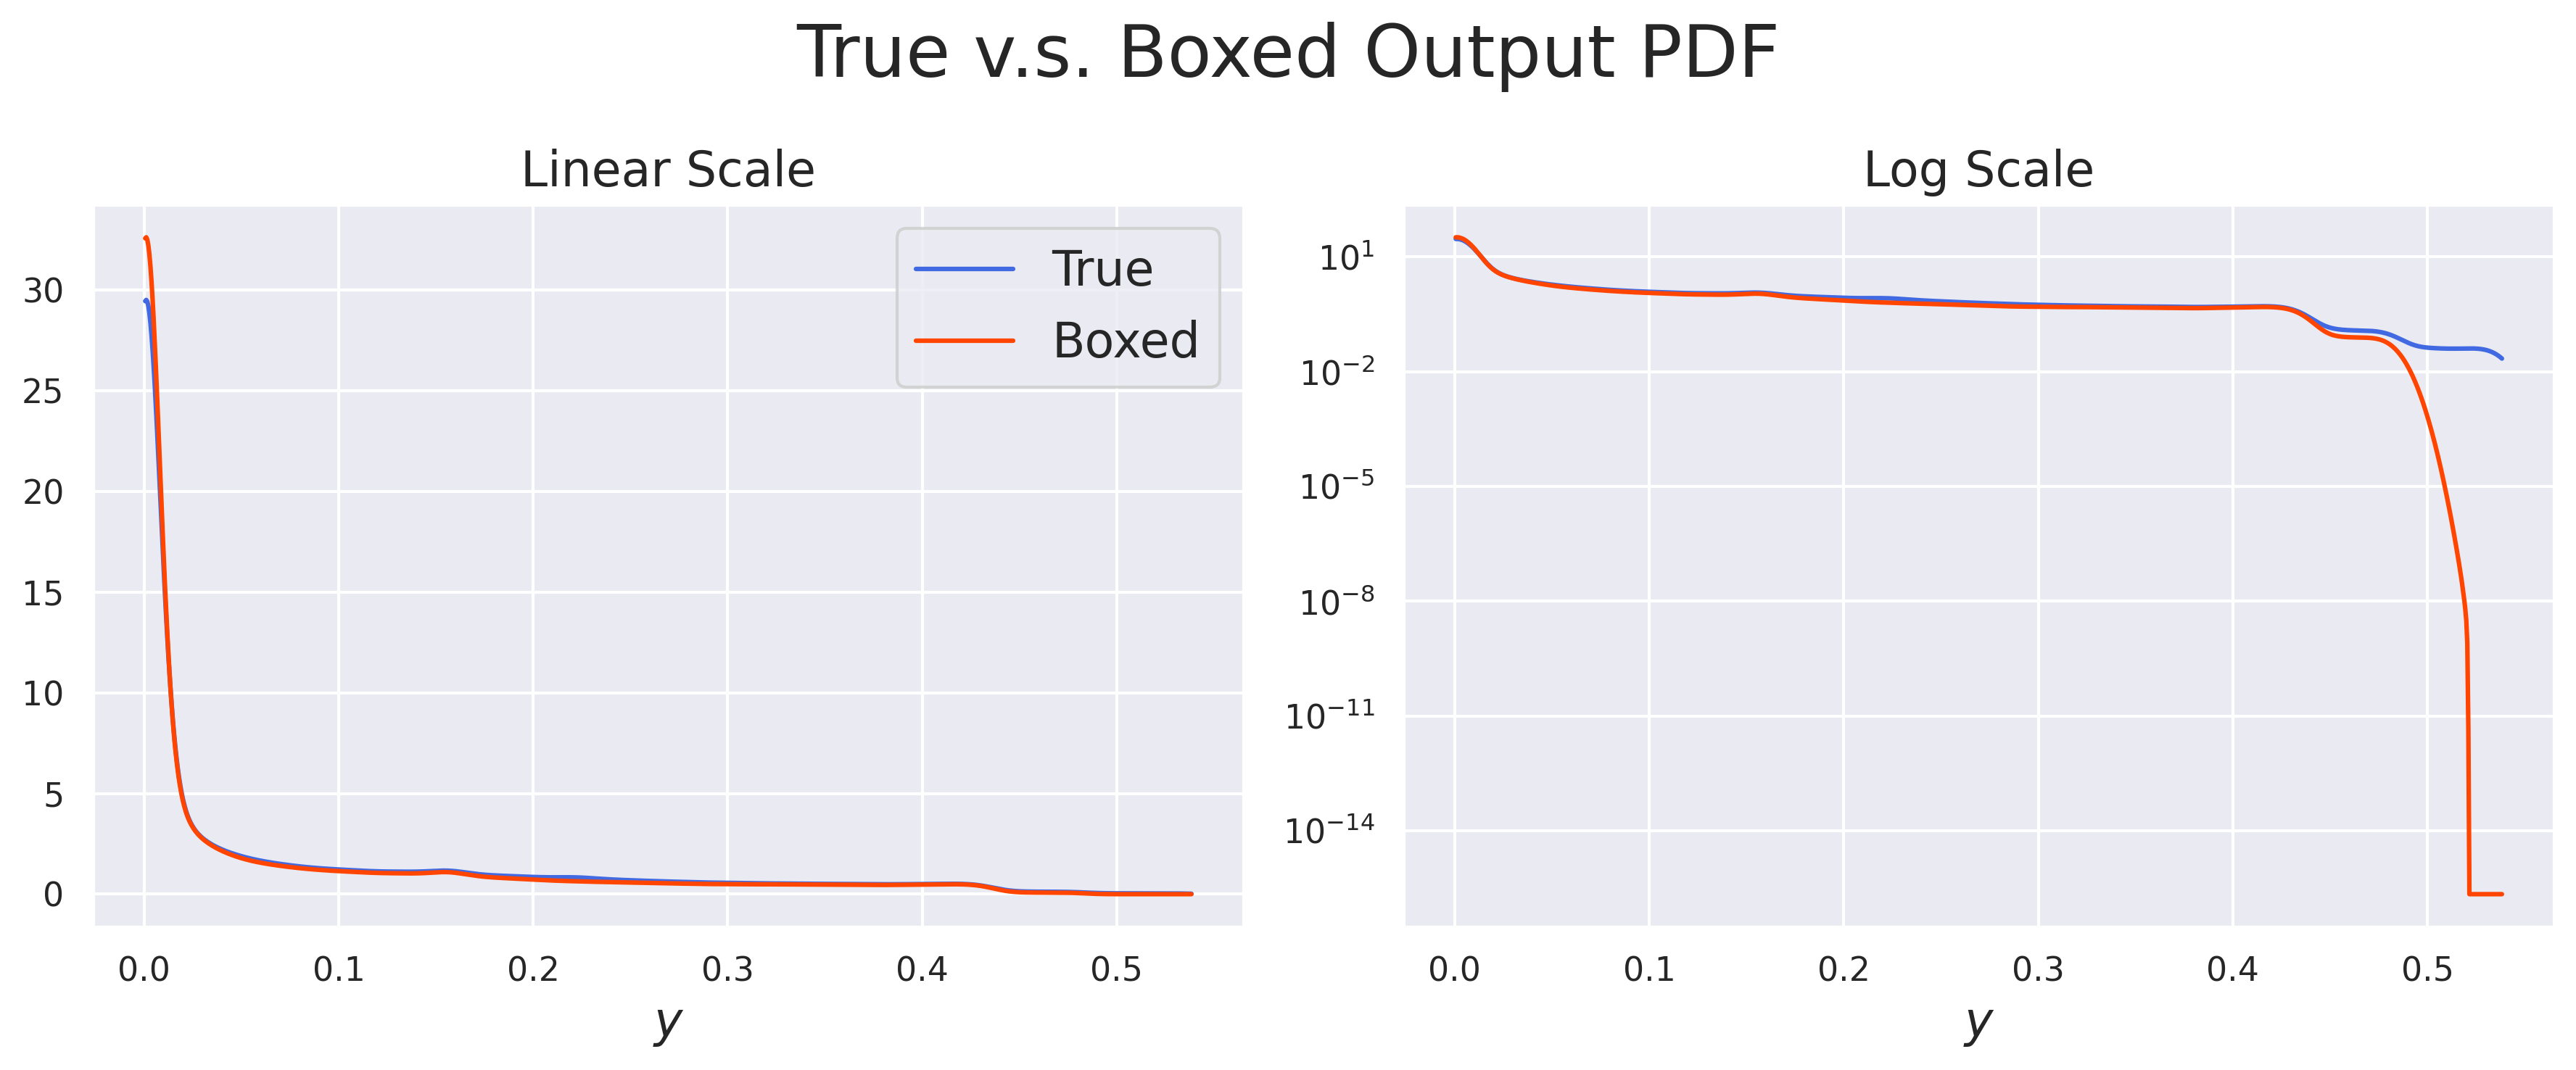

In [10]:
px_box = input_sampler.pdf(X_BOX)

# output pdf
y_box, py_box, box_output_pdf = get_data_pdf(Y_BOX, Y, None)

fig, ax = plt.subplots(1,2,figsize=(12,5),dpi=300)
ax[0].plot(y_true, py_true, color='royalblue', label="True")# label=r"$p_y(y)$")
ax[0].plot(y_box, py_box, color='orangered', label="Boxed")#label=r"$p_{\hat{y}}(y)$")
ax[0].set_title('Linear Scale', fontsize=16)
ax[0].set_xlabel(r"$y$", fontsize=16)
ax[0].legend(prop={'size':16})

ax[1].plot(y_true, py_true, color='royalblue')
ax[1].plot(y_box, py_box, color='orangered')
ax[1].set_yscale('log')
ax[1].set_title('Log Scale', fontsize=16)
ax[1].set_xlabel(r"$y$", fontsize=16)
# ax[1].set_ylabel(r"$\log{p_y(y)}$", fontsize=16)
plt.suptitle(fr"True v.s. Boxed Output PDF", fontsize=24)
plt.tight_layout()
# plt.savefig("./figs/true-box-pdf1.png")

### Select Training Data

In [11]:
n_train = 100
count = 0
idx = 0
train_idx = []
rand_idx = torch.randperm(Ns)
Xperm = X[rand_idx]
Yperm = Y[rand_idx]
while count < n_train:
    x_temp = Xperm[idx,]
    y_temp = Yperm[idx]
    if is_not_extreme(x_temp, mult=4.) and is_not_small(y_temp,thresh=0.005):
        train_idx.append(idx)
        count += 1
    idx += 1

x_train = Xperm[train_idx]
y_train = Yperm[train_idx]

### Visualize Training Data

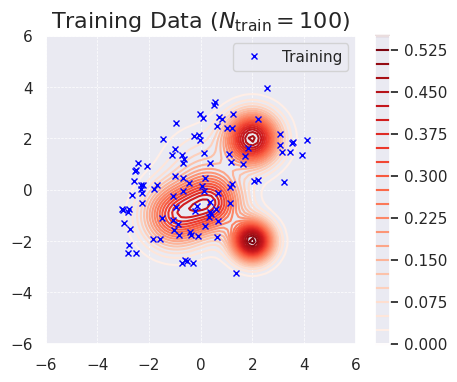

In [12]:
# plot training data

fig, ax = plt.subplots(figsize=(5,4), facecolor='w')
ax_lim = (-6,6)
plt2 = ax.contour(X1.numpy(),X2.numpy(),OUT_GRID.reshape(N,N).numpy(), 24, cmap='Reds')
plt.colorbar(plt2, ax=ax)
ax.set_xlim(ax_lim)
ax.set_ylim(ax_lim)
ax.grid(linestyle='--', linewidth=0.5)
ax.set_title(r"Training Data ($N_{\text{train}}" + f" = {n_train}$)", fontsize=16)
ax.plot(x_train[:,0], x_train[:,1], 'x', markersize=4, color='blue', alpha=1, label='Training')
ax.legend()
# plt.savefig(f'./figs/training-N{n_train}.png')

## Select Data with Extremes

In [214]:
count = 0
idx = 0
train_idx = []
rand_idx = torch.randperm(Ns)
Xperm = X[rand_idx]
Yperm = Y[rand_idx]
while count < n_train:
    x_temp = Xperm[idx,]
    y_temp = Yperm[idx]
    if is_not_small(y_temp,thresh=0.005):
        train_idx.append(idx)
        count += 1
    idx += 1

x_train_e = Xperm[train_idx]
y_train_e = Yperm[train_idx]

## Visualize Data with Extremes

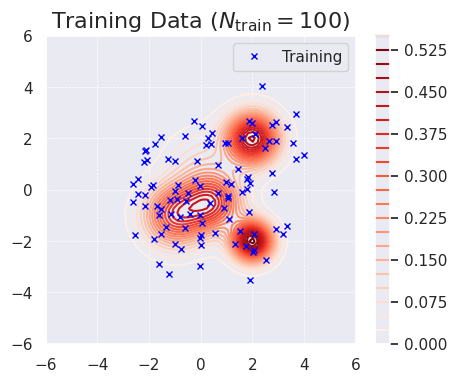

In [215]:
# plot training data

fig, ax = plt.subplots(figsize=(5,4), facecolor='w')
ax_lim = (-6,6)
plt2 = ax.contour(X1.numpy(),X2.numpy(),OUT_GRID.reshape(N,N).numpy(), 24, cmap='Reds')
plt.colorbar(plt2, ax=ax)
ax.set_xlim(ax_lim)
ax.set_ylim(ax_lim)
ax.grid(linestyle='--', linewidth=0.5)
ax.set_title(r"Training Data ($N_{\text{train}}" + f" = {n_train}$)", fontsize=16)
ax.plot(x_train_e[:,0], x_train_e[:,1], 'x', markersize=4, color='blue', alpha=1, label='Training')
ax.legend()
# plt.savefig(f'./figs/training-N{n_train}.png')

In [216]:
DATA = {
    'X_all' : X,
    'Y_all' : Y,
    'X_LHS' : LHS,
    'Y_LHS' : Y_LHS,
    'X_BOX' : X_BOX,
    'Y_BOX' : Y_BOX,
    'in_grid' : GRIDS,
    'out_grid' : OUT_GRID,
    'x_train' : x_train,
    'y_train' : y_train,
    'x_train_e' : x_train_e, 
    'y_train_e' : y_train_e
}
for val in DATA.values():
    print(type(val))

<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [218]:
if ADD_FOURIER:
    DATA_PATH = f'./data/toy-pert/var{var_in}-eoi{exloc}'
else:
    DATA_PATH = f'./data/toy/var{var_in}-eoi{exloc}'
print(DATA_PATH)

./data/toy/var10-eoi2.0


In [219]:
create_path(DATA_PATH)
FILE_NAME = DATA_PATH + f'/N{n_train}-LHS{N_LHS}.pth'
torch.save(DATA, FILE_NAME)

Directory './data/toy/var10-eoi2.0' created.


In [220]:
DATA2 = torch.load(FILE_NAME)
for key in DATA2.keys():
    print(key)

X_all
Y_all
X_LHS
Y_LHS
X_BOX
Y_BOX
in_grid
out_grid
x_train
y_train
x_train_e
y_train_e
